# 03 — Preprocessing
> Cleans the raw data: handles outliers, imputes missing values, encodes categoricals,
> applies target transforms, and saves a model-ready interim dataset.

**Prerequisite:** `01_data_ingestion.ipynb`

## 0 · Colab Setup

In [1]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !git clone https://github.com/YOUR_USERNAME/tree_carbon_ml.git 2>/dev/null || true
    %cd tree_carbon_ml
    !pip install -r requirements.txt -q
else:
    # If running locally inside the 'notebooks' folder, move up to the project root
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
# Add src to path
src_path = os.path.join(os.getcwd(), 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)
print(f'Environment ready. Working directory is now: {os.getcwd()}')

Environment ready. Working directory is now: c:\Users\janan\Documents\ML_Project\Air_Quality_Predictor


## 1 · Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from scipy import stats

pd.set_option('display.float_format', '{:.4f}'.format)
TARGET = 'TPH.gs.dC.dN0.01'

df = pd.read_parquet('data/interim/01_raw_validated.parquet')
print(f'Loaded: {df.shape}')
df.head(3)

Loaded: (110650, 23)


,PLT_CN,TPH.gs.dC.dN0.01,TPH.s.dC.dN0.01,TPH.g.dC.dN0.01,EXPN.ha,LAT,LON,EXPN.ha.TPH.gs.dC.dN0.01,EXPN.ha.TPH.s.dC.dN0.01,EXPN.ha.TPH.g.dC.dN0.01,...,STATECD,COUNTYCD,e3,e1,e4,e3.state,e4.state,e1.state,eco.EXPN.ha,state.EXPN.ha
0,106313473010478,6.4108,-33.3048,39.7156,2407.4985,31.3290,-88.3549,15434.0742,-80181.1827,95615.2568,...,1,129,8.3.5,8.0000,65f,8.3.5,65f,8,148681549.1796,9965556.6875
1,106313107010478,0.0000,0.0000,0.0000,2397.3487,31.2464,-88.2513,0.0000,0.0000,0.0000,...,1,129,8.3.5,8.0000,65f,8.3.5,65f,8,148681549.1796,9965556.6875
2,106331005010478,15.3826,-2.7670,18.1496,2367.5412,31.3412,-85.6098,36418.8536,-6551.0965,42969.9501,...,1,45,8.3.5,8.0000,65d,8.3.5,65d,8,148681549.1796,9965556.6875


## 2 · Define Column Groups

In [3]:
# Identifier columns (never used as features)
ID_COLS = ['PLT_CN']

# Target columns
TARGET_COLS = ['TPH.gs.dC.dN0.01', 'TPH.s.dC.dN0.01', 'TPH.g.dC.dN0.01',
               'EXPN.ha.TPH.gs.dC.dN0.01', 'EXPN.ha.TPH.s.dC.dN0.01', 'EXPN.ha.TPH.g.dC.dN0.01']
TARGET_COLS = [c for c in TARGET_COLS if c in df.columns]

# Categorical/ecoregion columns
CAT_COLS = ['US_L4CODE','NA_L3CODE','NA_L1CODE','e3','e1','e4',
            'e3.state','e4.state','e1.state']
CAT_COLS = [c for c in CAT_COLS if c in df.columns]

# Numeric feature columns
NUM_COLS = ['LAT','LON','EXPN.ha','eco.EXPN.ha','state.EXPN.ha']
NUM_COLS = [c for c in NUM_COLS if c in df.columns]

# State/county IDs (treat as categoricals)
GEO_ID_COLS = ['STATECD','COUNTYCD']
GEO_ID_COLS = [c for c in GEO_ID_COLS if c in df.columns]

print('ID cols        :', ID_COLS)
print('Target cols    :', TARGET_COLS)
print('Numeric cols   :', NUM_COLS)
print('Categorical cols:', CAT_COLS)
print('Geo ID cols    :', GEO_ID_COLS)

ID cols        : ['PLT_CN']
Target cols    : ['TPH.gs.dC.dN0.01', 'TPH.s.dC.dN0.01', 'TPH.g.dC.dN0.01', 'EXPN.ha.TPH.gs.dC.dN0.01', 'EXPN.ha.TPH.s.dC.dN0.01', 'EXPN.ha.TPH.g.dC.dN0.01']
Numeric cols   : ['LAT', 'LON', 'EXPN.ha', 'eco.EXPN.ha', 'state.EXPN.ha']
Categorical cols: ['US_L4CODE', 'NA_L3CODE', 'NA_L1CODE', 'e3', 'e1', 'e4', 'e3.state', 'e4.state', 'e1.state']
Geo ID cols    : ['STATECD', 'COUNTYCD']


## 3 · Remove Exact Duplicates

In [4]:
n_before = len(df)
df = df.drop_duplicates(subset=['PLT_CN']).reset_index(drop=True)
print(f'Rows before: {n_before:,}  |  After dedup: {len(df):,}  |  Removed: {n_before-len(df):,}')

Rows before: 110,650  |  After dedup: 110,650  |  Removed: 0


## 4 · Outlier Handling
We use **IQR-based winsorization** (capping) rather than dropping rows, to preserve spatial coverage.

In [5]:
def winsorize_col(series: pd.Series, lower_pct=0.01, upper_pct=0.99) -> pd.Series:
    lo, hi = series.quantile(lower_pct), series.quantile(upper_pct)
    return series.clip(lo, hi)

df_clean = df.copy()

# Winsorize target at 1st–99th percentile
for col in TARGET_COLS:
    before = df_clean[col].describe()
    df_clean[col] = winsorize_col(df_clean[col])
    print(f'{col}: min {before["min"]:.2f} → {df_clean[col].min():.2f} | '
          f'max {before["max"]:.2f} → {df_clean[col].max():.2f}')

# Winsorize numeric features
for col in NUM_COLS:
    df_clean[col] = winsorize_col(df_clean[col])

print('\nWinsorization complete.')

TPH.gs.dC.dN0.01: min -602.52 → -109.47 | max 2128.60 → 182.91
TPH.s.dC.dN0.01: min -634.74 → -157.93 | max 1916.88 → 46.31
TPH.g.dC.dN0.01: min -189.90 → -11.74 | max 1225.65 → 172.20
EXPN.ha.TPH.gs.dC.dN0.01: min -4631891.37 → -266743.75 | max 11670586.84 → 483603.82
EXPN.ha.TPH.s.dC.dN0.01: min -6357755.46 → -404673.87 | max 7936996.83 → 112558.03
EXPN.ha.TPH.g.dC.dN0.01: min -2409687.23 → -25100.22 | max 9501393.37 → 497955.00

Winsorization complete.


In [6]:
# Verify coordinate validity after winsorization
print('LAT range after clean:', df_clean['LAT'].min(), '→', df_clean['LAT'].max())
print('LON range after clean:', df_clean['LON'].min(), '→', df_clean['LON'].max())

# Remove any rows where coordinates are clearly invalid (0,0)
invalid_coords = (df_clean['LAT'] == 0) | (df_clean['LON'] == 0)
print(f'Invalid coordinate rows: {invalid_coords.sum()}')
df_clean = df_clean[~invalid_coords].reset_index(drop=True)
print(f'Rows after coord filter: {len(df_clean):,}')

LAT range after clean: 29.69999287 → 48.7036339
LON range after clean: -123.86453193 → -68.82057209999999
Invalid coordinate rows: 0
Rows after coord filter: 110,650


## 5 · Missing Value Imputation

In [7]:
print('Missing values before imputation:')
miss = df_clean.isna().sum()
display(miss[miss > 0])

Missing values before imputation:


US_L4CODE    29
NA_L3CODE    29
NA_L1CODE    29
e3           29
e1           29
e4           29
dtype: int64

In [8]:
# Numeric: median imputation (robust to skew)
if df_clean[NUM_COLS].isna().any().any():
    num_imputer = SimpleImputer(strategy='median')
    df_clean[NUM_COLS] = num_imputer.fit_transform(df_clean[NUM_COLS])
    print('Numeric imputation done.')

# Categoricals: fill with 'UNKNOWN'
for col in CAT_COLS + GEO_ID_COLS:
    n_miss = df_clean[col].isna().sum()
    if n_miss > 0:
        df_clean[col] = df_clean[col].fillna('UNKNOWN')
        print(f'  {col}: filled {n_miss} nulls with UNKNOWN')

print('\nMissing values after imputation:')
miss_after = df_clean.isna().sum()
print(miss_after[miss_after > 0] if miss_after.any() else '✅ None')

  US_L4CODE: filled 29 nulls with UNKNOWN
  NA_L3CODE: filled 29 nulls with UNKNOWN
  NA_L1CODE: filled 29 nulls with UNKNOWN
  e3: filled 29 nulls with UNKNOWN
  e1: filled 29 nulls with UNKNOWN
  e4: filled 29 nulls with UNKNOWN

Missing values after imputation:
✅ None


## 6 · Categorical Encoding
Encode ecoregion codes using **Label Encoding** for tree-based models and one-hot for linear models.

In [9]:
# Label Encoding (for gradient boosting / tree models)
label_encoders = {}
for col in CAT_COLS + GEO_ID_COLS:
    le = LabelEncoder()
    df_clean[f'{col}_enc'] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    print(f'  {col} → {col}_enc  ({len(le.classes_)} classes)')

print('\nLabel encoding done.')

  US_L4CODE → US_L4CODE_enc  (779 classes)
  NA_L3CODE → NA_L3CODE_enc  (82 classes)
  NA_L1CODE → NA_L1CODE_enc  (11 classes)
  e3 → e3_enc  (82 classes)
  e1 → e1_enc  (11 classes)
  e4 → e4_enc  (779 classes)
  e3.state → e3.state_enc  (81 classes)
  e4.state → e4.state_enc  (778 classes)
  e1.state → e1.state_enc  (10 classes)
  STATECD → STATECD_enc  (48 classes)
  COUNTYCD → COUNTYCD_enc  (194 classes)

Label encoding done.


In [10]:
# One-Hot Encoding for high-level ecoregions (L1 only — low cardinality)
ohe_cols = ['NA_L1CODE']
ohe_cols = [c for c in ohe_cols if c in df_clean.columns]
df_ohe = pd.get_dummies(df_clean[ohe_cols], prefix=ohe_cols, drop_first=True)
df_clean = pd.concat([df_clean, df_ohe], axis=1)
print(f'Added {df_ohe.shape[1]} OHE columns for {ohe_cols}')
print('OHE columns:', df_ohe.columns.tolist())

Added 10 OHE columns for ['NA_L1CODE']
OHE columns: ['NA_L1CODE_6.0', 'NA_L1CODE_7.0', 'NA_L1CODE_8.0', 'NA_L1CODE_9.0', 'NA_L1CODE_10.0', 'NA_L1CODE_11.0', 'NA_L1CODE_12.0', 'NA_L1CODE_13.0', 'NA_L1CODE_15.0', 'NA_L1CODE_UNKNOWN']


## 7 · Target Transformations
Create multiple transformed versions of the target for different model types.

In [11]:
# 1. Signed log transform (handles both positive and negative values)
df_clean['target_log'] = np.sign(df_clean[TARGET]) * np.log1p(np.abs(df_clean[TARGET]))

# 2. Binary classification target (sink vs source)
df_clean['target_binary'] = (df_clean[TARGET] > 0).astype(int)

# 3. Tertile-based multiclass (strong sink / neutral / strong source)
q33, q66 = df_clean[TARGET].quantile(0.33), df_clean[TARGET].quantile(0.66)
df_clean['target_class3'] = pd.cut(
    df_clean[TARGET],
    bins=[-np.inf, q33, q66, np.inf],
    labels=[0, 1, 2]  # 0=source, 1=neutral, 2=sink
).astype(int)

print('Target transform stats:')
for col in ['TPH.gs.dC.dN0.01','target_log','target_binary','target_class3']:
    print(f'  {col}: {df_clean[col].describe().to_dict()}')

Target transform stats:
  TPH.gs.dC.dN0.01: {'count': 110650.0, 'mean': 6.868836908888028, 'std': 37.283227615374685, 'min': -109.47048336426292, '25%': -5.71204228353945, '50%': 1.369861715940165, '75%': 15.607590747172626, 'max': 182.9061923227131}
  target_log: {'count': 110650.0, 'mean': 0.5139942237362592, 'std': 2.652114605714764, 'min': -4.704748366399757, '25%': -1.9039032687381798, '50%': 0.8628316050665913, '75%': 2.809859864763481, 'max': 5.214425803271292}
  target_binary: {'count': 110650.0, 'mean': 0.5480976050610031, 'std': 0.49768349267065, 'min': 0.0, '25%': 0.0, '50%': 1.0, '75%': 1.0, 'max': 1.0}
  target_class3: {'count': 110650.0, 'mean': 1.0099954812471759, 'std': 0.8184807043717441, 'min': 0.0, '25%': 0.0, '50%': 1.0, '75%': 2.0, 'max': 2.0}


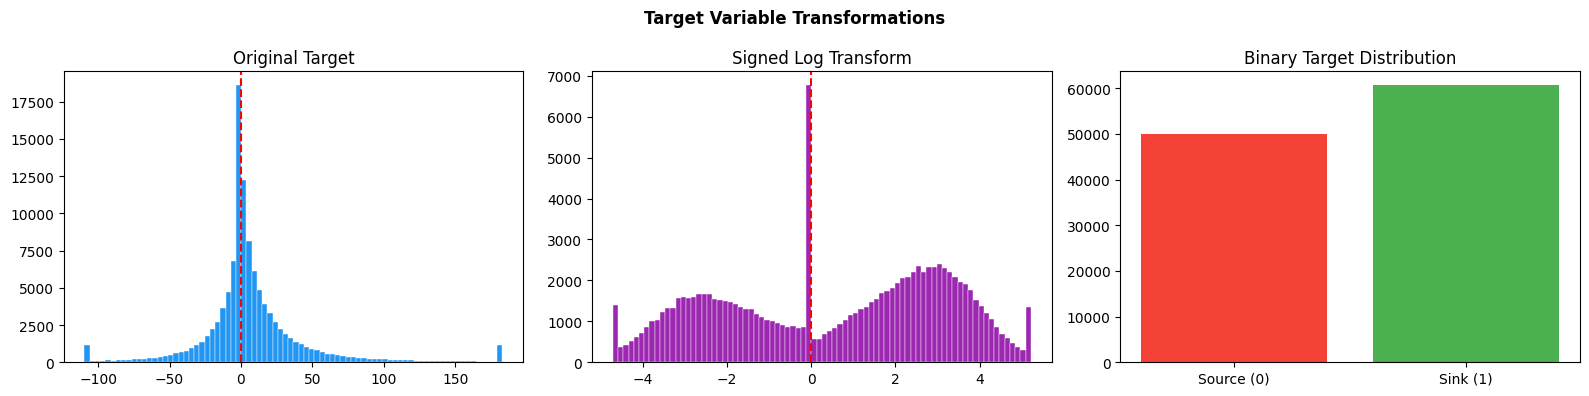

In [12]:
# Visualize transforms
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_clean[TARGET].dropna(), bins=80, color='#2196F3', edgecolor='white', lw=0.3)
axes[0].set_title('Original Target'); axes[0].axvline(0,color='red',ls='--')

axes[1].hist(df_clean['target_log'].dropna(), bins=80, color='#9C27B0', edgecolor='white', lw=0.3)
axes[1].set_title('Signed Log Transform'); axes[1].axvline(0,color='red',ls='--')

axes[2].bar(['Source (0)','Sink (1)'],
            df_clean['target_binary'].value_counts().sort_index().values,
            color=['#F44336','#4CAF50'])
axes[2].set_title('Binary Target Distribution')

fig.suptitle('Target Variable Transformations', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/08_target_transforms.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 · Feature Scaling

In [13]:
# RobustScaler — preferred for skewed distributions
robust_scaler = RobustScaler()
scale_cols = NUM_COLS.copy()

scaled_arr = robust_scaler.fit_transform(df_clean[scale_cols].fillna(0))
scaled_df = pd.DataFrame(scaled_arr, columns=[f'{c}_scaled' for c in scale_cols])
df_clean = pd.concat([df_clean.reset_index(drop=True), scaled_df.reset_index(drop=True)], axis=1)

print('RobustScaler applied to:', scale_cols)
print('Scaled column sample stats:')
display(scaled_df.describe().round(3))

RobustScaler applied to: ['LAT', 'LON', 'EXPN.ha', 'eco.EXPN.ha', 'state.EXPN.ha']
Scaled column sample stats:


,LAT_scaled,LON_scaled,EXPN.ha_scaled,eco.EXPN.ha_scaled,state.EXPN.ha_scaled
count,110650.0000,110650.0000,110650.0000,110650.0000,110650.0000
mean,0.0200,-0.1470,-0.1440,-0.4610,-0.0080
std,0.5710,0.5960,1.8260,0.5080,0.7620
min,-1.0410,-1.2930,-3.2800,-1.3330,-1.8270
25%,-0.4620,-0.7090,-0.6820,-1.0000,-0.5100
50%,-0.0000,-0.0000,0.0000,0.0000,0.0000
75%,0.5380,0.2910,0.3180,0.0000,0.4900
max,0.9590,0.8240,8.2480,0.0000,1.2920


## 9 · Preprocessing Quality Report

In [14]:
print('=== Preprocessing Summary ===')
print(f'Final shape      : {df_clean.shape}')
print(f'Remaining nulls  : {df_clean.isna().sum().sum()}')
print(f'Numeric cols     : {df_clean.select_dtypes(include=np.number).shape[1]}')
print(f'Encoded cat cols : {len(label_encoders)}')
print(f'OHE cols added   : {df_ohe.shape[1]}')
print(f'Target transforms: target_log, target_binary, target_class3')

# Skewness before/after log transform
print(f'\nTarget skewness:')
print(f'  Original  : {df_clean[TARGET].skew():.3f}')
print(f'  Log-transf: {df_clean["target_log"].skew():.3f}')

=== Preprocessing Summary ===
Final shape      : (110650, 52)
Remaining nulls  : 0
Numeric cols     : 33
Encoded cat cols : 11
OHE cols added   : 10
Target transforms: target_log, target_binary, target_class3

Target skewness:
  Original  : 1.351
  Log-transf: -0.202


## 10 · Save Preprocessed Dataset

In [15]:
import os
os.makedirs('data/interim', exist_ok=True)
# ---> Fix: Automatically find all "object" (mixed/text) columns and convert them to pure strings <---
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].astype(str)
out_path = 'data/interim/03_preprocessed.parquet'
df_clean.to_parquet(out_path, index=False)
print(f'Saved: {out_path}  shape={df_clean.shape}')
# Also save column manifest
manifest = {
    'id_cols': ID_COLS,
    'target_cols': TARGET_COLS + ['target_log','target_binary','target_class3'],
    'numeric_cols': NUM_COLS,
    'categorical_cols': CAT_COLS + GEO_ID_COLS,
    'encoded_cols': [f'{c}_enc' for c in CAT_COLS + GEO_ID_COLS],
    'scaled_cols': [f'{c}_scaled' for c in scale_cols],
    'ohe_cols': df_ohe.columns.tolist(),
}
import json
with open('data/interim/03_column_manifest.json','w') as f:
    json.dump(manifest, f, indent=2)
print('Column manifest saved to data/interim/03_column_manifest.json')

Saved: data/interim/03_preprocessed.parquet  shape=(110650, 52)
Column manifest saved to data/interim/03_column_manifest.json


---
### ✅ Notebook 03 Complete
Next: **04_feature_extraction.ipynb**